## KNN Classifier (n=5) Accuracy: 0.8203
## Gradient Boosting Classifier Accuracy: 0.9456

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("data/ObesityDataSet_raw_and_data_sinthetic.csv")
X = df.drop(columns=["NObeyesdad"])
y = df["NObeyesdad"]

print(f"\n{df['CAEC'].value_counts().to_string()}")
print(f"\n{df['CALC'].value_counts().to_string()}")
print(f"\n{df['MTRANS'].value_counts().to_string()}")


CAEC
Sometimes     1765
Frequently     242
Always          53
no              51

CALC
Sometimes     1401
no             639
Frequently      70
Always           1

MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7


In [21]:
X['Gender'] = X['Gender'].map({"Female": 0, "Male": 1})
X['family_history_with_overweight'] = X['family_history_with_overweight'].map({"no": 0, "yes": 1})
X['FAVC'] = X['FAVC'].map({"no": 0, "yes": 1})
X['CAEC'] = X['CAEC'].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
X['SMOKE'] = X['SMOKE'].map({"no": 0, "yes": 1})
X['SCC'] = X['SCC'].map({"no": 0, "yes": 1})
X['CALC'] = X['CALC'].map({"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3})
X['MTRANS'] = X['MTRANS'].map({"Automobile": 0, "Motorbike": 1, "Bike": 2, "Public_Transportation": 3, "Walking": 4})
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


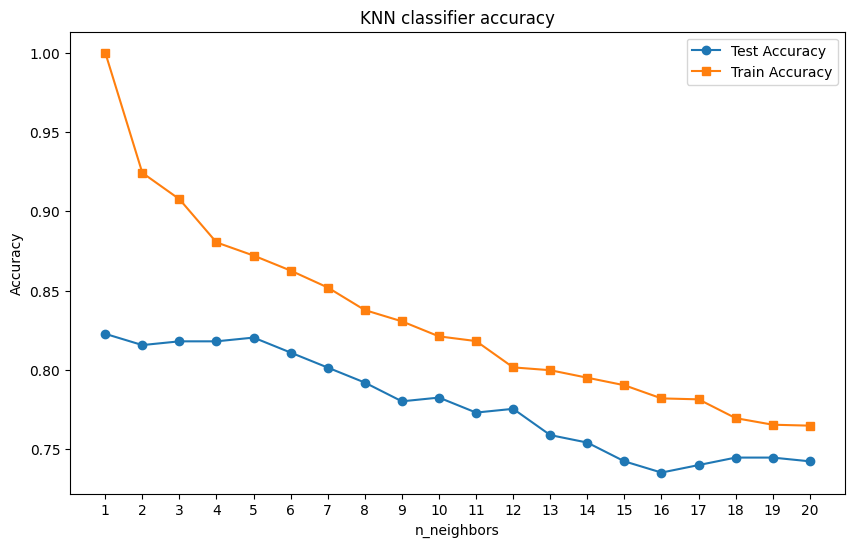

In [ ]:
accuracy_scores_test = []
accuracy_scores_train = []
for n in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores_test.append(accuracy)
    accuracy_scores_train.append(knn.score(X_train_scaled, y_train))
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), accuracy_scores_test, marker='o')
plt.plot(range(1, 21), accuracy_scores_train, marker='s')
plt.title("KNN classifier accuracy")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.legend(["Test Accuracy", "Train Accuracy"])
plt.savefig("knn_accuracy.png")
plt.show()

In [ ]:
# final knn----n=5
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_scaled, y_train)

print(f'Accuracy of KNN (n=5) on training set: {knn_final.score(X_train_scaled, y_train):.4f}')
print(f'Accuracy of KNN (n=5) on test set: {knn_final.score(X_test_scaled, y_test):.4f}\n')

Accuracy of KNN (n=5) on training set: 0.8720
Accuracy of KNN (n=5) on test set: 0.8203



In [26]:
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train_scaled, y_train)

print(f'Accuracy of Gradient Boosted DTs on training set: {gbc.score(X_train_scaled, y_train):.4f}')
print(f'Accuracy of Gradient Boosted DTs on test set: {gbc.score(X_test_scaled, y_test):.4f}\n')

Accuracy of Gradient Boosted DTs on training set: 1.0000
Accuracy of Gradient Boosted DTs on test set: 0.9456



                       Feature  Importance
                         SMOKE    0.000211
family_history_with_overweight    0.001048
                        MTRANS    0.001894
                           SCC    0.002078
                          FAVC    0.009249
                           TUE    0.010240
                           FAF    0.010978
                           NCP    0.014898
                          CAEC    0.015567
                          CALC    0.022789
                          CH2O    0.030976
                           Age    0.040170
                        Gender    0.080456
                          FCVC    0.088552
                        Height    0.116296
                        Weight    0.554599


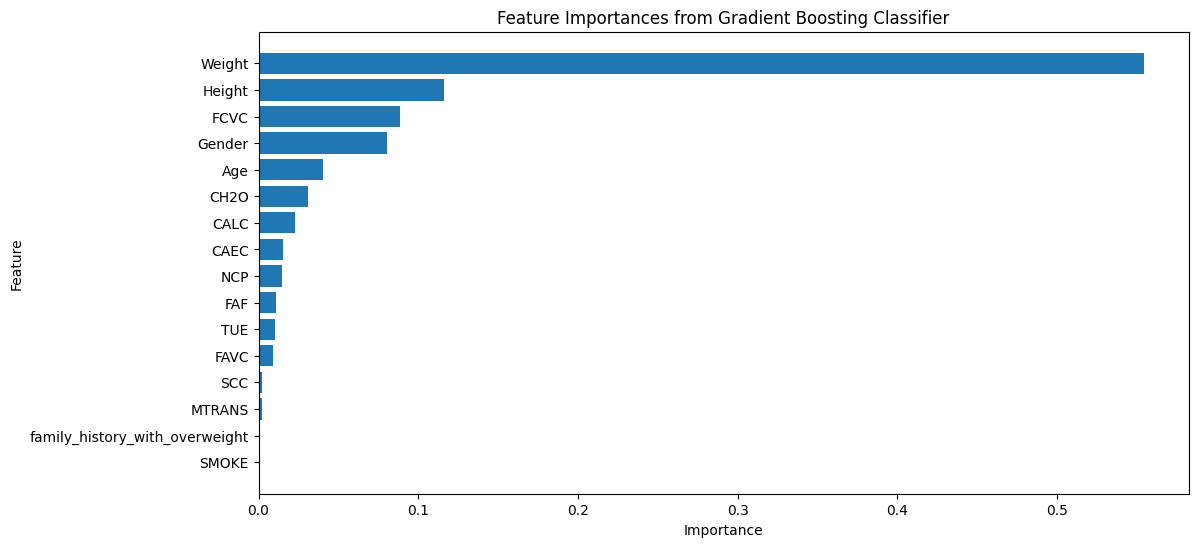

In [30]:
# Feature importance plot for Gradient Boosting Classifier
feature_importances = gbc.feature_importances_
feature_names = X.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
df_importance = df_importance.sort_values(by='Importance')
print(df_importance.to_string(index=False))
plt.figure(figsize=(12, 6))
plt.barh(df_importance['Feature'], df_importance['Importance'])
plt.title("Feature Importances from Gradient Boosting Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("feature_importance.png")
plt.show()